# `witwin.channel.deterministic.solve_field` Elevated 3D Three Cubes

This notebook uses `witwin.channel.core.scene` together with `witwin.channel.deterministic.solve_field`.
It mirrors the deterministic radiomap elevated-transmitter three-cube scene with a dense field monitor plane, then plots total forward field and AD-vs-FD total-power gradients for `tx_x` and `cube1_x`. It also runs small-grid LoS-only backward VJP checks against the forward-mode JVP sum.

The default visualization workflow runs at `256 x 256` resolution with 3D full-sphere reflection sampling.


In [1]:
from pathlib import Path
import importlib
import math
import sys

from IPython.display import display
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve()
if not (repo_root / "witwin").exists():
    repo_root = next(path for path in repo_root.parents if (path / "witwin").exists())
repo_root_str = str(repo_root)
sys.path = [path for path in sys.path if str(Path(path or ".").resolve()) != repo_root_str]
sys.path.insert(0, repo_root_str)

importlib.invalidate_caches()
for module_name in tuple(sys.modules):
    if module_name == "witwin" or module_name.startswith((
        "examples.field_solver_three_cubes_3d",
        "witwin.",
    )):
        sys.modules.pop(module_name, None)

import examples.field_solver_three_cubes_3d as fs3

DEFAULT_FD_STEP = fs3.DEFAULT_FD_STEP
ThreeCubeField3DExperiment = fs3.ThreeCubeField3DExperiment
plot_forward = fs3.plot_forward
plot_gradient = fs3.plot_gradient

experiment = ThreeCubeField3DExperiment(
    grid_shape=(256, 256),
    forward_num_samples=384,
    gradient_num_samples=128,
    reflection_max_bounces=3,
    max_diffraction_order=1,
)

display({
    "experiment": {
        "grid_shape": experiment.grid_shape,
        "tx_pos": experiment.tx_pos,
        "plane_z": experiment.plane_z,
        "ray_mode": experiment.field_spec().ray_mode,
        "ray_sampling": experiment.field_spec().ray_sampling,
        "reflection_max_bounces": experiment.reflection_max_bounces,
        "max_diffraction_order": experiment.max_diffraction_order,
    },
})

experiment


jitc_llvm_init(): LLVM API initialization failed ..


{'experiment': {'grid_shape': (256, 256),
  'tx_pos': (0.0, -5.0, 4.0),
  'plane_z': 1.0,
  'ray_mode': '3d',
  'ray_sampling': 'full_sphere',
  'reflection_max_bounces': 3,
  'max_diffraction_order': 1}}

{'total_power_shape': (256, 256), 'epc_stats': None}

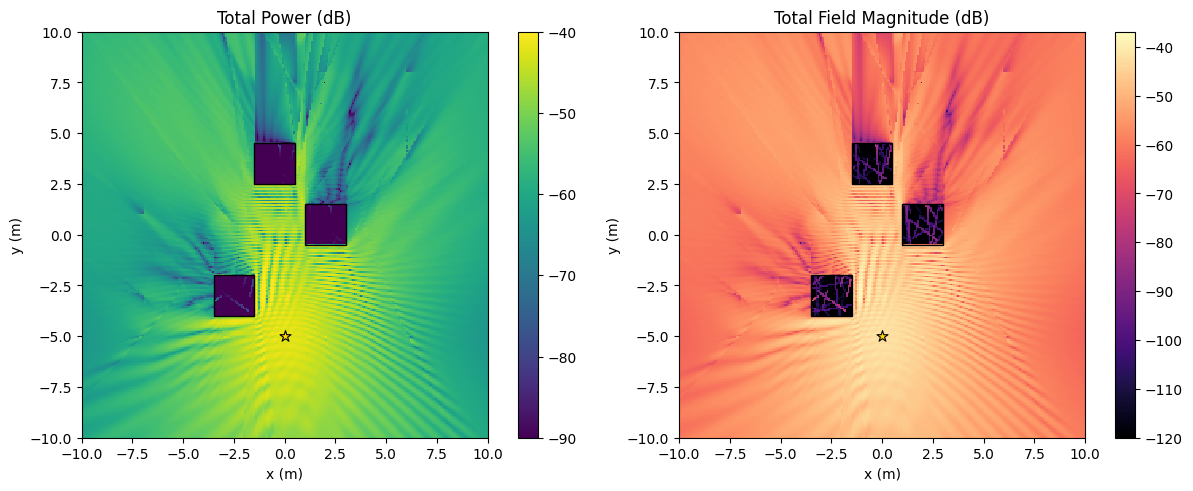

In [2]:
forward = experiment.forward()
display({
    "total_power_shape": tuple(int(value) for value in forward.total_power.shape),
    "epc_stats": forward.metadata.get("epc_stats"),
})
plot_forward(forward)
plt.show()


{'parameter': 'tx_x',
 'ad_l1': 1.119687396751468,
 'fd_l1': 0.9443282784789819,
 'delta_l1': 0.41838648421050634}

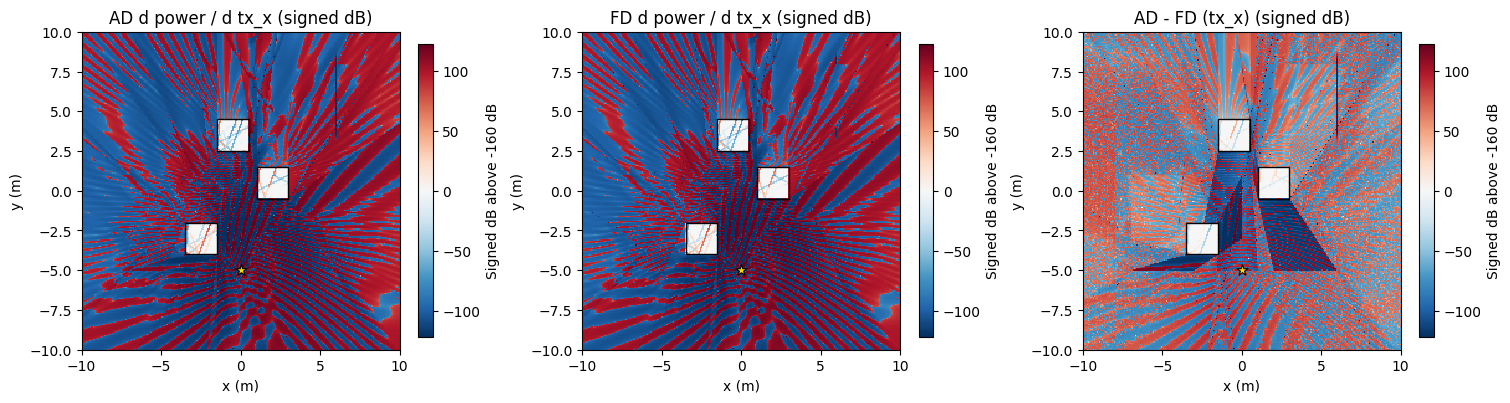

In [3]:
tx_gradient = experiment.gradient("tx_x")
display({
    "parameter": tx_gradient.parameter,
    "ad_l1": float(abs(tx_gradient.ad).sum()),
    "fd_l1": float(abs(tx_gradient.fd).sum()),
    "delta_l1": float(abs(tx_gradient.delta).sum()),
})
plot_gradient(tx_gradient)
plt.show()


{'parameter': 'cube1_x',
 'ad_l1': 1.1373050787424845,
 'fd_l1': 1.0760346508490637,
 'delta_l1': 0.20365473489133604}

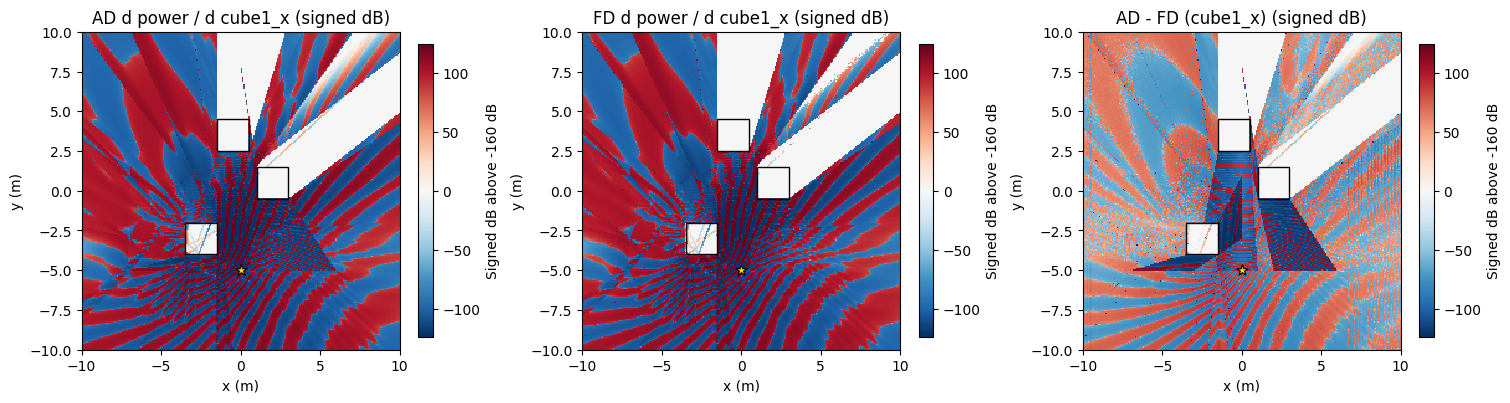

In [4]:
cube_gradient = experiment.gradient("cube1_x")
display({
    "parameter": cube_gradient.parameter,
    "ad_l1": float(abs(cube_gradient.ad).sum()),
    "fd_l1": float(abs(cube_gradient.fd).sum()),
    "delta_l1": float(abs(cube_gradient.delta).sum()),
})
plot_gradient(cube_gradient)
plt.show()


In [5]:
# Backward/VJP smoke check
backward_experiment = ThreeCubeField3DExperiment(
    grid_shape=(16, 16),
    forward_num_samples=32,
    gradient_num_samples=16,
    reflection_max_bounces=0,
    max_diffraction_order=0,
)
backward_checks = {
    parameter: backward_experiment.backward(
        parameter,
        grid_shape=(8, 8),
        num_samples=16,
        fd_step=DEFAULT_FD_STEP,
    )
    for parameter in ("tx_x", "cube1_x")
}
summary = {
    parameter: {
        "vjp": float(snapshot.vjp),
        "jvp_sum": float(snapshot.jvp_sum),
        "fd_sum": float(snapshot.fd_sum),
        "vjp_minus_jvp_sum": float(snapshot.vjp_delta),
        "vjp_minus_fd_sum": float(snapshot.fd_delta),
    }
    for parameter, snapshot in backward_checks.items()
}
display(summary)
for snapshot in backward_checks.values():
    assert math.isfinite(snapshot.vjp)
    assert abs(snapshot.vjp_delta) <= max(1.0e-7, 1.0e-4 * max(1.0, abs(snapshot.jvp_sum)))


{'tx_x': {'vjp': 1.4125730558589566e-06,
  'jvp_sum': 1.4126424048299668e-06,
  'fd_sum': 0.0001714385575724009,
  'vjp_minus_jvp_sum': -6.934897101018578e-11,
  'vjp_minus_fd_sum': -0.00017002598451654194},
 'cube1_x': {'vjp': 0.0,
  'jvp_sum': 0.0,
  'fd_sum': 0.0,
  'vjp_minus_jvp_sum': 0.0,
  'vjp_minus_fd_sum': 0.0}}